# Week 9 Phase 1.10 closure diagnostics

Three cheap checks close the external validation without changing its frozen primary verdict: recover the generic separator's raw exponent, remove transition labels, and relax logistic regularization.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, Markdown, display
ROOT=Path.cwd().resolve().parents[1]
OUT=ROOT/'outputs'/'week9_phase1_10_closure_diagnostics'
print('closure artifacts:',OUT)

closure artifacts: C:\Users\ozgur\Documents\thesis-week9-phase1-10-closure-diagnostics\outputs\week9_phase1_10_closure_diagnostics


## 1. Why the checks matter

The generic model beat the fixed physics direction in the frozen bundle-level protocol. That difference could reflect a rotated P–VX separator, the transition-to-Keyhole mapping, or the fixed C=1 regularization. These are sensitivities, not replacement primary analyses.

## 2. Raw-scale exponent recovery algebra

Training predictors were standardized. Therefore `beta_P=gamma_P/sigma_P`, `beta_VX=gamma_VX/sigma_VX`, and `alpha=beta_VX/beta_P`. The standardized coefficient ratio is generally wrong. Five fold estimates are averaged inside each repeat before uncertainty is calculated.

In [2]:
folds=pd.read_csv(OUT/'exponent_fold_estimates.csv')
repeat=pd.read_csv(OUT/'exponent_repeat_summary.csv')
summary=pd.read_csv(OUT/'exponent_summary.csv')
display(folds.groupby('material').agg(fits=('alpha','size'),valid=('alpha_valid','sum'),betaP_min=('beta_P','min'),betaP_max=('beta_P','max')))

,fits,valid,betaP_min,betaP_max
material,,,,
316L,100,99,-0.473460,9.606162
Ti64,100,100,-1.661203,7.047373


## 3–5. Ti64, 316L, and the predeclared −0.5 reference

The interval is a grouped split-sensitivity interval, not a physical-population confidence interval and not proof of a causal exponent.

,material,summary_type,setting,alpha_mean,alpha_median,ci_lower,ci_upper,q25,q75,minimum,...,valid_fits,invalid_fits,beta_P_sign_flips,beta_VX_sign_flips,theory_alpha,delta_alpha,theory_status,interval_scope,beta_P,beta_VX
0,Ti64,grouped_cv_repeat_block,R1_C1,-1.71300,-1.64049,-1.89312,-1.52087,-1.87344,-1.56256,-2.62470,...,100,0,1,0,-0.5,-1.21300,THEORY_OFFSET_RESOLVED,split-sensitivity over 20 repeat means; five f...,NaN,NaN
1,Ti64,descriptive_full_data,R1_C1,-1.46481,-1.46481,NaN,NaN,NaN,NaN,-1.46481,...,1,0,0,0,-0.5,-0.96481,DESCRIPTIVE_ONLY,complete-data descriptive fit; no predictive-p...,3.70844,-5.43214
2,316L,grouped_cv_repeat_block,R1_C1,-1.21953,-1.27756,-1.45974,-0.90596,-1.38302,-1.18003,-2.56701,...,99,1,1,0,-0.5,-0.71953,THEORY_OFFSET_RESOLVED,split-sensitivity over 20 repeat means; five f...,NaN,NaN
3,316L,descriptive_full_data,R1_C1,-1.08344,-1.08344,NaN,NaN,NaN,NaN,-1.08344,...,1,0,0,0,-0.5,-0.58344,DESCRIPTIVE_ONLY,complete-data descriptive fit; no predictive-p...,4.90030,-5.30917


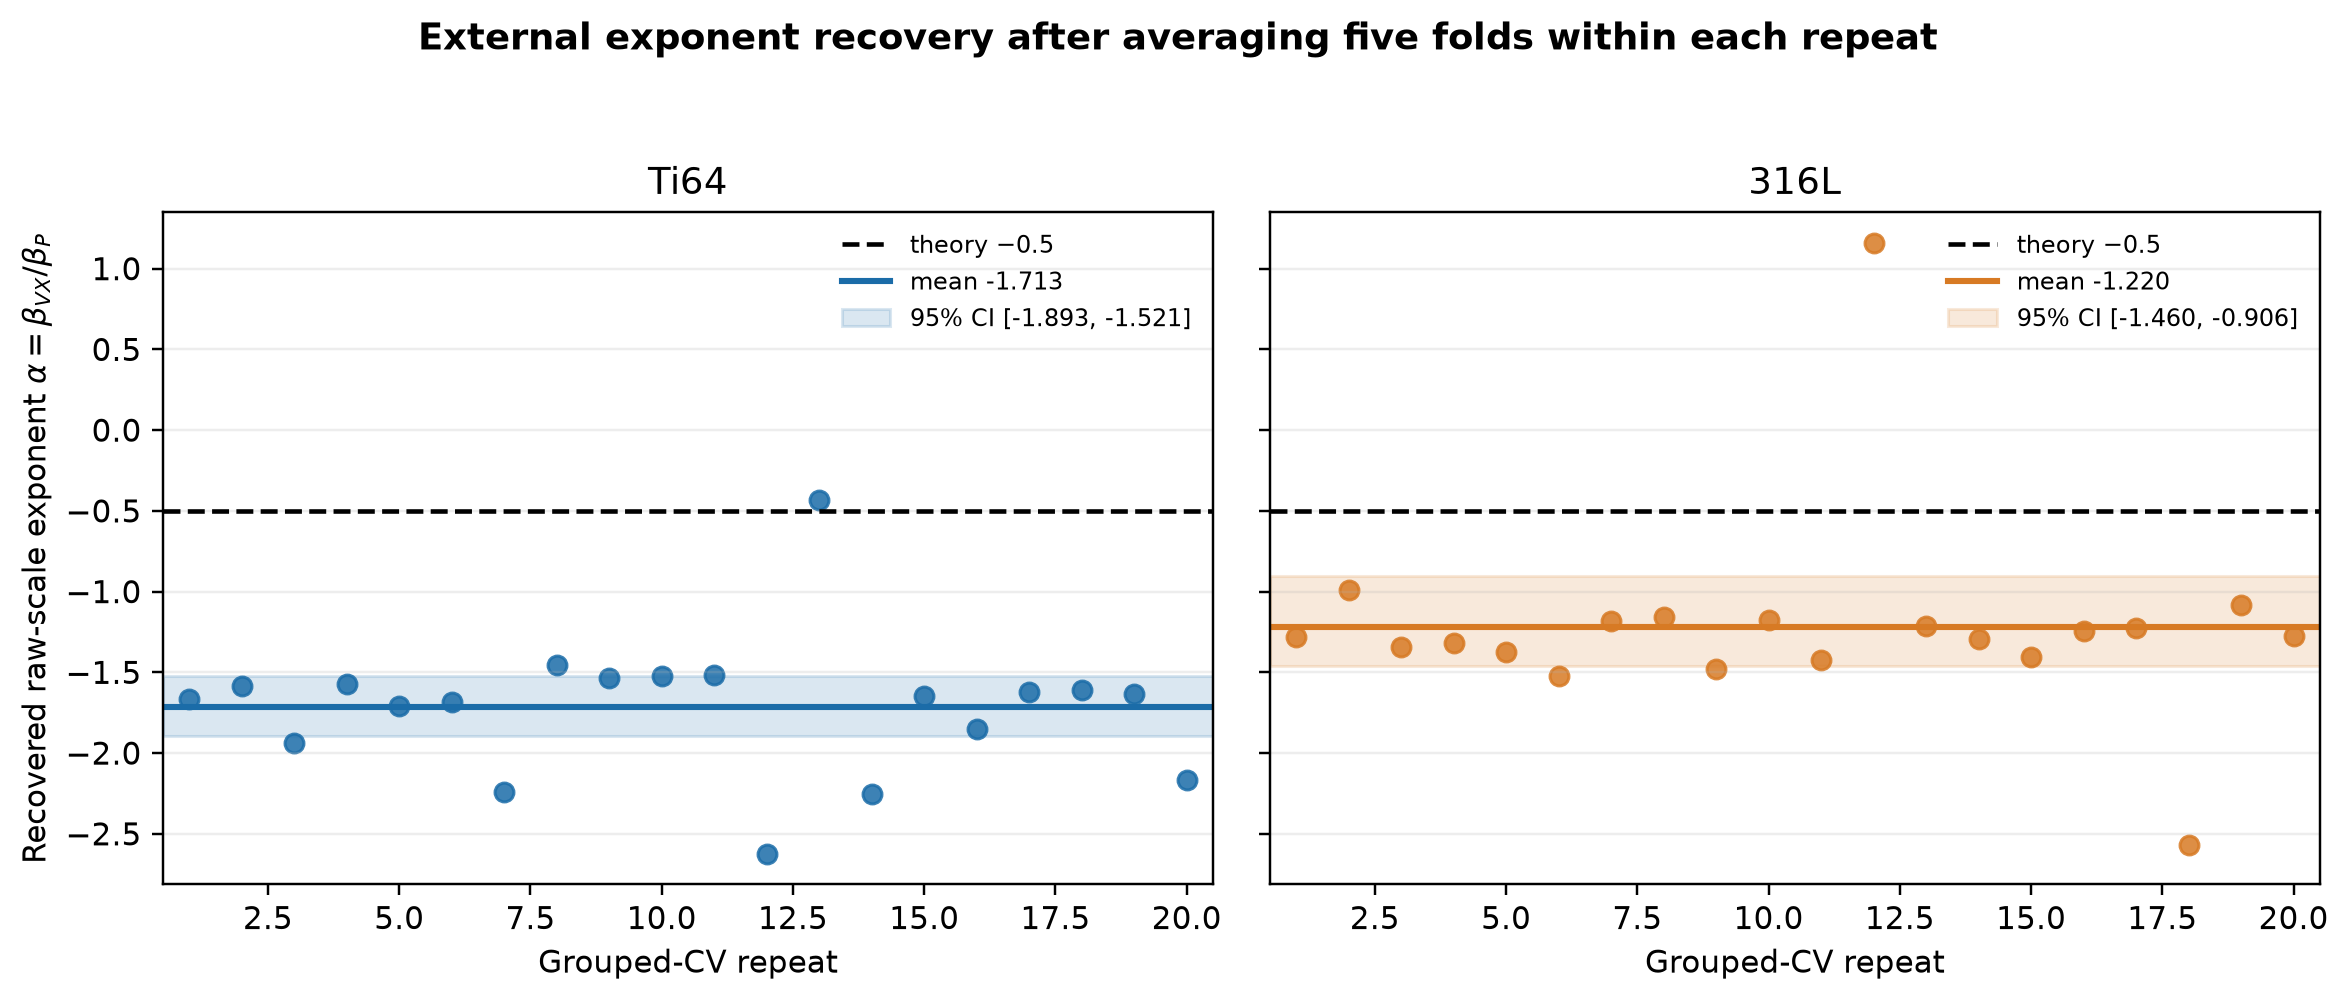

In [3]:
display(summary.round(5))
display(Image(filename=str(OUT/'figures'/'01_recovered_alpha_by_repeat.png')))

## 6. Strict C-versus-K audit

Only raw `C` and pure `K` rows remain. `T`, `CT`, and `TK` are removed, not remapped. Exact repeated process conditions stay grouped.

In [4]:
audit=pd.read_csv(OUT/'strict_ck_population_audit.csv')
display(audit)

,material,bundles,unique_conditions,mode_C,mode_K,repeated_conditions,discordant_conditions,folds,repeats,both_classes_every_heldout_fold
0,Ti64,48,32,26,22,14,0,5,20,True
1,316L,48,32,37,11,14,0,5,20,True


## 7. Strict C-versus-K model results

H and G use the same train-only scaling and C=1 logistic implementation as the frozen primary experiment. Complete OOF vectors are scored once per repeat.

metric          balanced_accuracy  brier_score  keyhole_recall  pr_auc  \
material model                                                           
316L     G                 0.9545       0.0224          0.9091     1.0   
         H                 0.9545       0.0207          0.9091     1.0   
Ti64     G                 1.0000       0.0320          1.0000     1.0   
         H                 1.0000       0.0322          1.0000     1.0   

metric          roc_auc  
material model           
316L     G          1.0  
         H          1.0  
Ti64     G          1.0  
         H          1.0

,dataset,material,setting,contrast,metric,mean_difference,ci_lower,ci_upper,repeat_blocks,bootstrap_draws,interval_scope
0,strict_C_vs_K,Ti64,R1_C1,H_minus_G,roc_auc,0.0,0.0,0.0,20,10000,split sensitivity over paired repeat blocks
7,strict_C_vs_K,316L,R1_C1,H_minus_G,roc_auc,0.0,0.0,0.0,20,10000,split sensitivity over paired repeat blocks


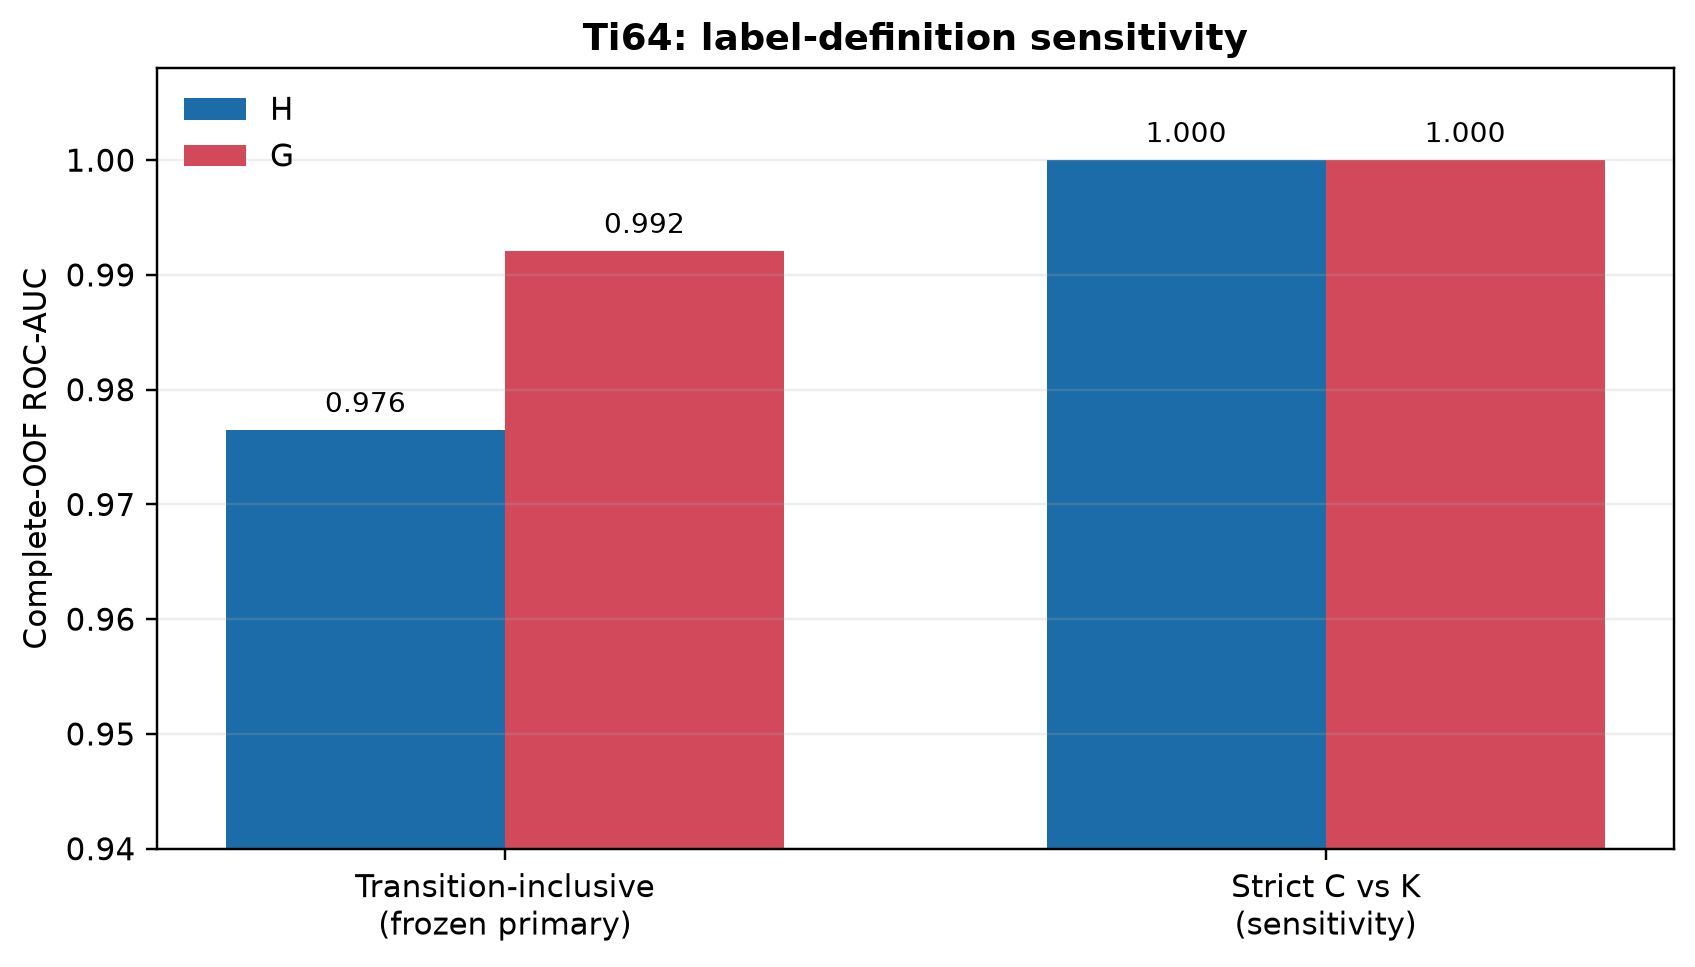

In [5]:
strict=pd.read_csv(OUT/'strict_ck_model_summary.csv')
contrast=pd.read_csv(OUT/'strict_ck_paired_contrasts.csv')
display(strict[strict.metric.isin(['roc_auc','pr_auc','balanced_accuracy','keyhole_recall','brier_score'])].pivot_table(index=['material','model'],columns='metric',values='mean').round(4))
display(contrast.query("metric=='roc_auc'").round(5))
display(Image(filename=str(OUT/'figures'/'02_ti64_transition_vs_strict_ck.png')))

## 8. Regularization sensitivity

R1 is frozen C=1; R2 is weak regularization C=1e6. `penalty=None` is recorded unavailable because the installed API emits a deprecation warning. No result-driven C selection is made.

In [6]:
reg=pd.read_csv(OUT/'regularization_sensitivity.csv')
display(reg.round(5))

,dataset,material,setting,status,implementation,H_roc_auc,G_roc_auc,H_minus_G_roc_auc,H_minus_G_ci_lower,H_minus_G_ci_upper,alpha_mean,alpha_ci_lower,alpha_ci_upper,valid_coefficient_fits,invalid_coefficient_fits,converged_fraction,beta_P_positive_fraction,beta_VX_negative_fraction,beta_P_near_zero_count,alpha_extreme_count
0,transition_inclusive,Ti64,R1_C1,AVAILABLE,lbfgs; train-only scaling; C=1.0,0.97647,0.99208,-0.01561,-0.01663,-0.01454,-1.71300,-1.89524,-1.51855,100.0,0.0,1.0,0.99,1.0,0.0,0.0
1,transition_inclusive,Ti64,R2_C1e6,AVAILABLE,lbfgs; train-only scaling; C=1000000.0,0.96776,0.95317,0.01459,0.01247,0.01657,-2.33402,-2.54298,-2.09535,99.0,1.0,1.0,1.00,1.0,0.0,1.0
2,transition_inclusive,Ti64,R3_unpenalized,R3_UNAVAILABLE,R3_UNAVAILABLE: penalty=None emits a deprecati...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,strict_C_vs_K,Ti64,R1_C1,AVAILABLE,lbfgs; train-only scaling; C=1.0,1.00000,1.00000,0.00000,0.00000,0.00000,-1.69965,-1.90943,-1.50419,96.0,4.0,1.0,1.00,1.0,0.0,4.0
4,strict_C_vs_K,Ti64,R2_C1e6,AVAILABLE,lbfgs; train-only scaling; C=1000000.0,1.00000,1.00000,0.00000,0.00000,0.00000,-1.30204,-1.38282,-1.24005,100.0,0.0,1.0,1.00,1.0,0.0,0.0
5,strict_C_vs_K,Ti64,R3_unpenalized,R3_UNAVAILABLE,R3_UNAVAILABLE: penalty=None emits a deprecati...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 9. Final Phase 1.10 interpretation

The frozen `GENERIC_DIRECTION_SUPERIOR` verdict remains unchanged. These diagnostics state whether the generic gain requires a materially different exponent, transition inclusion, or C=1 regularization.

In [7]:
display(Markdown((OUT/'SUPERVISOR_PHASE1_10_CLOSURE_ONE_PAGE.md').read_text()))

# Supervisor one-page â€” Phase 1.10 closure

## Frozen result

Phase 1.10 remains **GENERIC_DIRECTION_SUPERIOR** under its predeclared bundle-level protocol (Hâˆ’G ROC-AUC -0.0156 [-0.0167, -0.0145]).

## Three closure answers

1. **External exponent:** Ti64 alpha=-1.7130 [-1.8931, -1.5209] (THEORY_OFFSET_RESOLVED; 100/100 valid); 316L alpha=-1.2195 [-1.4597, -0.9060] (THEORY_OFFSET_RESOLVED; 99/100 valid). Coefficients were converted back from standardized to raw log-input scale; instability and sign flips are explicit.
2. **Strict C/K:** Ti64 H/G ROC-AUC=1.0000/1.0000, Hâˆ’G=+0.0000 [+0.0000, +0.0000]. 316L H/G=1.0000/1.0000.
3. **Regularization:** transition-inclusive Ti64 Hâˆ’G is -0.0156 at C=1 and +0.0146 at C=1e6; recovered alpha is -1.7130/-2.3340. The sign reversal makes G>H regularization-sensitive. `penalty=None` was not run because the installed API emits a deprecation warning.

## Safe thesis interpretation

The experimental map strongly supports a monotone physics-aligned Pâ€“VX organization, but its C=1 logistic optimum is materially steeper than âˆ’0.5. Pure C/K is perfectly ranked by both H and G; transition labels create the frozen performance gap. That gap reverses under weak regularization, so it is not penalty-robust. The frozen primary verdict remains real for its declared protocol, but no exact exponent agreement, LS exponent, universal law, causal exponent, or active-learning benefit is established.


## 10. What remains untested

Constant LS cannot validate the `LS^-3/2` exponent. Classifier orientation is not a causal material law. Strict C/K is not identical to the thesis target. No active-learning, cross-material coefficient transfer, or universal threshold was tested.